1. Imports necesarios

In [3]:
from keras.datasets import mnist
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import matplotlib.pyplot as plt
import numpy as np

2. Carga de datos

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

3. Limpieza y preparación de datos

In [5]:
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

print(f"X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}")

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train.shape: (60000, 784), X_test.shape: (10000, 784)


4. Entrenamiento del modelo

In [6]:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_train)

KMeans(n_clusters=10, random_state=42)

5. Predicción

In [7]:
y_pred = kmeans.predict(X_test)

6. Cácuclo de accuracy

In [8]:
labels = np.zeros_like(y_pred)

for i in range(10):
    mask = (y_pred == i)
    if np.sum(mask) > 0:
        labels[mask] = mode(y_test[mask], keepdims=True).mode[0]

acc = accuracy_score(y_test, labels)
print(f"Accuracy: {acc}")

Accuracy: 0.5846


7. Gráfica de centroides

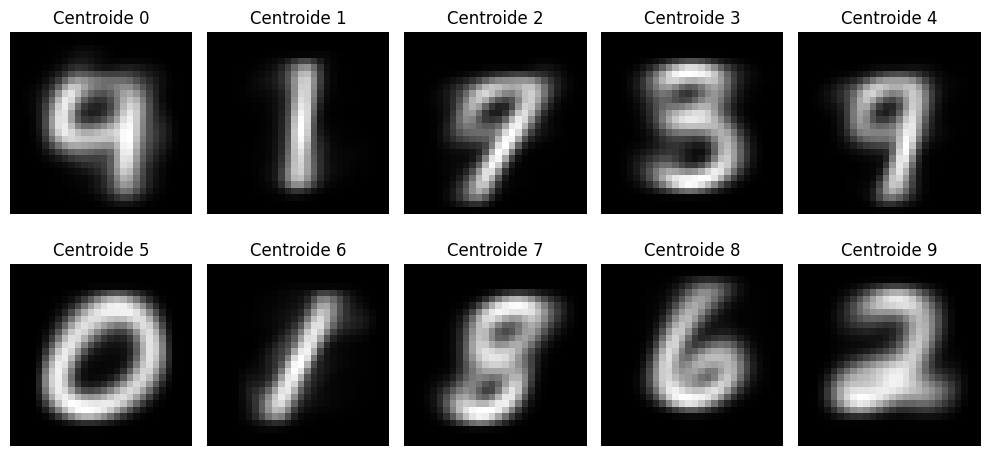

In [9]:
centroids = kmeans.cluster_centers_.reshape(10, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(centroids[i], cmap='gray')
    ax.set_title(f"Centroide {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()